# Evaluating Linear Regression on Housing Data

##  Course Details

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 821 Machine Learning
##### **Module:** Module 3 Linear Regression
##### **Name:** Marrion Kiprop Cherop** 
##### **Reg Number:** ST62/80971/2024



In [1]:
# Import necessary libraries
import numpy as np
import gdown
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Google Drive file ID
file_id = "11EtjqCR7KcbPB_NyFvFWRcDTEoW47UYF"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file from Drive
gdown.download(url, "housing.csv", quiet=False)

# Load into pandas
HousingData = pd.read_csv("housing.csv")

# Inspect first 5 rows
HousingData.head()

Downloading...
From: https://drive.google.com/uc?id=11EtjqCR7KcbPB_NyFvFWRcDTEoW47UYF
To: /home/langstkip/workspace/myOUK_Masters/MLS-SEM2/CSA821/housing.csv
100%|██████████| 568k/568k [00:00<00:00, 969kB/s]


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
HousingData.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [4]:
HousingData_numeric = HousingData.drop('Address', axis=1)

In [5]:
# Separate features (X) and target variable (y)
X = HousingData_numeric.drop('Price', axis=1)  # All features except 'Price'
y = HousingData_numeric['Price']  # The target variable is the house prices

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of the training and test sets
(X_train.shape, X_test.shape)

((4000, 5), (1000, 5))

In [6]:
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model on the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

In [7]:
# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Mean Squared Error (MSE): 10089009299.50
R-squared (R²): 0.92


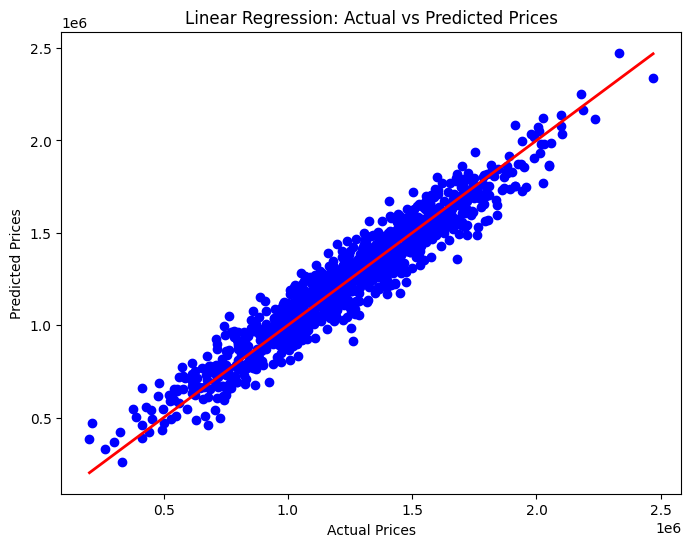

In [8]:
# Plotting the predicted vs. actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)  # Ideal line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.show()